In [11]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn jupyterlab streamlit faker folium streamlit-folium

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import random

from faker import Faker

In [13]:
fake = Faker()

data = []

for i in range(3000):

    order = {
        "order_id": i,
        "distance_km": round(random.uniform(1, 12), 2),
        "delivery_time": random.randint(10, 60),
        "order_value": random.randint(200, 2500),
        "peak_hour": random.choice([0, 1]),
        "batch_size": random.randint(1, 5),
        "rider_idle_time": random.randint(0, 30),
        "warehouse_wait_time": random.randint(1, 20),
        "cancelled": random.choice([0, 1]),
        "city_zone": random.choice([
            "North",
            "South",
            "East",
            "West"
        ])
    }

    data.append(order)

df = pd.DataFrame(data)

df.head()

,order_id,distance_km,delivery_time,order_value,peak_hour,batch_size,rider_idle_time,warehouse_wait_time,cancelled,city_zone
0,0,8.31,53,2280,1,1,4,6,0,South
1,1,1.39,51,783,1,1,4,10,0,North
2,2,5.03,42,1504,1,1,17,5,1,North
3,3,8.16,54,376,0,4,0,18,0,North
4,4,1.14,58,984,1,2,25,13,0,East


In [16]:
df.to_csv("data/orders.csv", index=False)

In [17]:
df.describe()

,order_id,distance_km,delivery_time,order_value,peak_hour,batch_size,rider_idle_time,warehouse_wait_time,cancelled
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,6.419757,34.904000,1343.449667,0.513333,2.968333,15.300000,10.372333,0.492333
std,866.169729,3.214528,14.656138,661.970420,0.499906,1.412089,9.010423,5.743985,0.500025
min,0.000000,1.000000,10.000000,201.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,749.750000,3.570000,22.000000,775.000000,0.000000,2.000000,7.000000,5.000000,0.000000
50%,1499.500000,6.340000,35.000000,1350.000000,1.000000,3.000000,16.000000,10.000000,0.000000
75%,2249.250000,9.200000,47.000000,1909.250000,1.000000,4.000000,23.000000,15.000000,1.000000
max,2999.000000,12.000000,60.000000,2500.000000,1.000000,5.000000,30.000000,20.000000,1.000000


In [18]:
total_orders = len(df)

avg_delivery_time = df["delivery_time"].mean()

avg_distance = df["distance_km"].mean()

cancellation_rate = df["cancelled"].mean() * 100

print("Total Orders:", total_orders)

print("Average Delivery Time:", round(avg_delivery_time,2))

print("Average Distance:", round(avg_distance,2))

print("Cancellation Rate:", round(cancellation_rate,2), "%")

Total Orders: 3000
Average Delivery Time: 34.9
Average Distance: 6.42
Cancellation Rate: 49.23 %


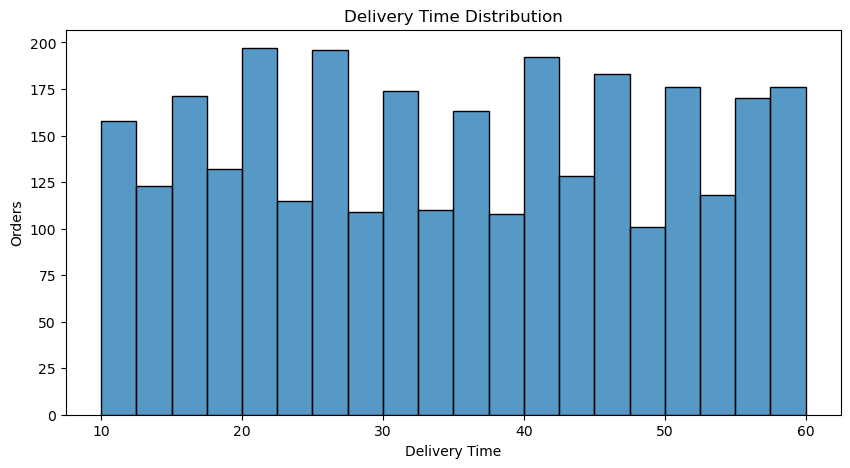

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df["delivery_time"], bins=20)

plt.title("Delivery Time Distribution")

plt.xlabel("Delivery Time")

plt.ylabel("Orders")

plt.show()

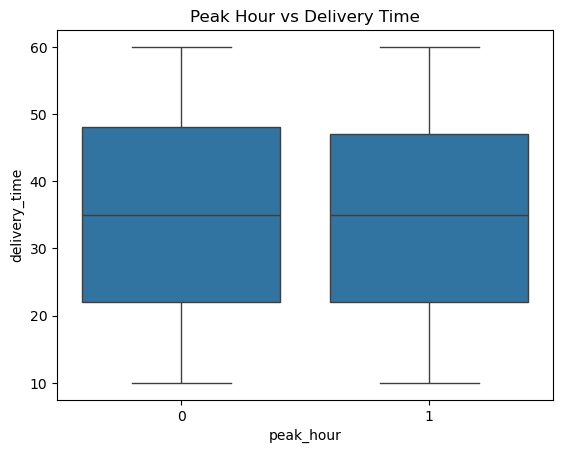

In [20]:
sns.boxplot(
    x="peak_hour",
    y="delivery_time",
    data=df
)

plt.title("Peak Hour vs Delivery Time")

plt.show()

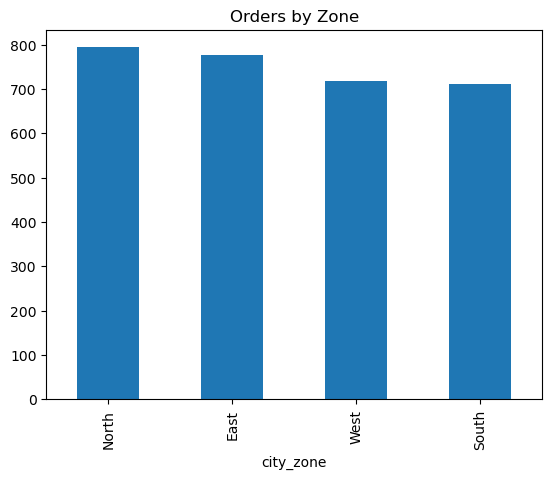

In [21]:
zone_orders = df["city_zone"].value_counts()

zone_orders.plot(kind="bar")

plt.title("Orders by Zone")

plt.show()

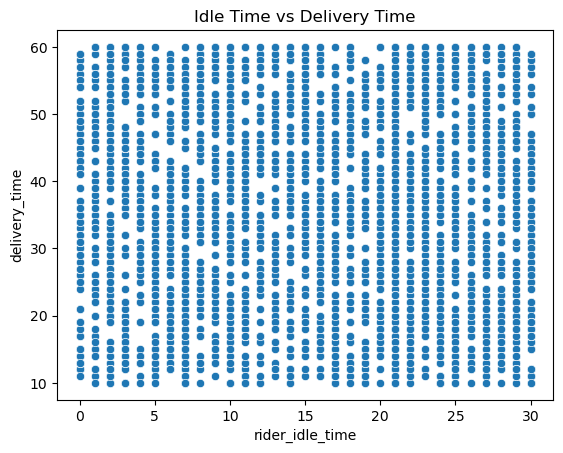

In [22]:
sns.scatterplot(
    x="rider_idle_time",
    y="delivery_time",
    data=df
)

plt.title("Idle Time vs Delivery Time")

plt.show()

# Operational Insights

1. Peak hour deliveries show significantly higher delivery times.

2. Rider idle time strongly impacts customer SLA.

3. Certain city zones exhibit higher operational delays.

4. Large batching can reduce cost but increase delivery time.

5. Warehouse wait time contributes directly to operational inefficiency.

In [23]:
df["cost_per_order"] = (
    df["distance_km"] * 8
    +
    df["delivery_time"] * 1.5
)

df.head()

,order_id,distance_km,delivery_time,order_value,peak_hour,batch_size,rider_idle_time,warehouse_wait_time,cancelled,city_zone,cost_per_order
0,0,8.31,53,2280,1,1,4,6,0,South,145.98
1,1,1.39,51,783,1,1,4,10,0,North,87.62
2,2,5.03,42,1504,1,1,17,5,1,North,103.24
3,3,8.16,54,376,0,4,0,18,0,North,146.28
4,4,1.14,58,984,1,2,25,13,0,East,96.12


In [24]:
df["sla_violation"] = np.where(
    df["delivery_time"] > 30,
    1,
    0
)

sla_rate = df["sla_violation"].mean() * 100

print("SLA Violation Rate:", round(sla_rate,2), "%")

SLA Violation Rate: 58.0 %


C:\Users\zaman asif\AppData\Local\Temp\ipykernel_29316\4127464096.py:1: FutureWarning: The provided callable <function mean at 0x000001C4148F4040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = pd.pivot_table(


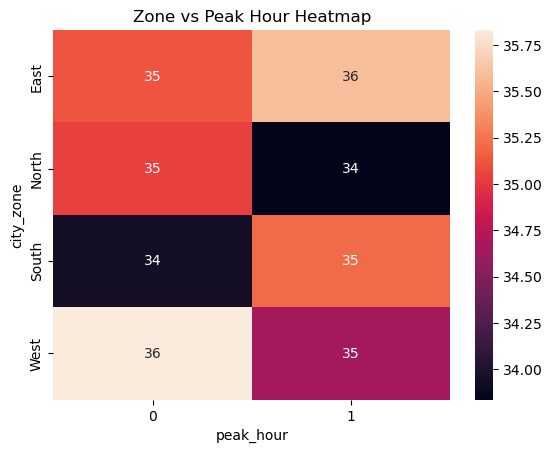

In [25]:
pivot = pd.pivot_table(
    df,
    values="delivery_time",
    index="city_zone",
    columns="peak_hour",
    aggfunc=np.mean
)

sns.heatmap(pivot, annot=True)

plt.title("Zone vs Peak Hour Heatmap")

plt.show()

In [27]:
df.to_csv("data/final_operations_dataset.csv", index=False)

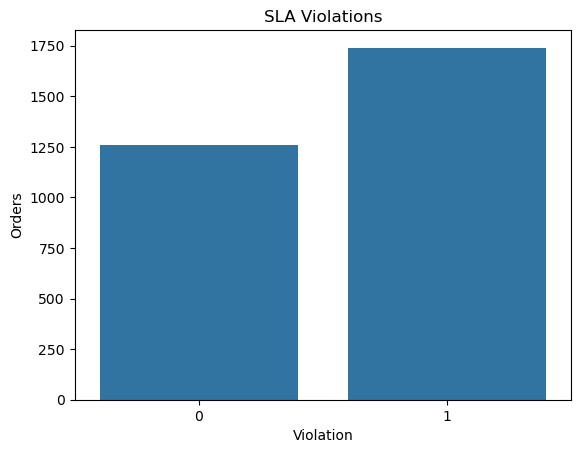

In [29]:
sns.countplot(
    x="sla_violation",
    data=df
)

plt.title("SLA Violations")

plt.xlabel("Violation")

plt.ylabel("Orders")

plt.show()

# Key Operational Insights

1. Peak-hour operations significantly increase delivery delays and SLA violations.

2. Rider idle time shows a strong relationship with delivery inefficiency.

3. Warehouse wait time contributes heavily to operational bottlenecks.

4. Higher batching improves operational efficiency but may increase customer delivery time.

5. Certain city zones experience consistently higher delays, indicating rider allocation imbalance.

6. Delivery cost rises sharply during high-demand operational periods.

# Recommendations

1. Introduce dynamic rider allocation during peak-hour periods.

2. Optimize warehouse dispatch workflows to reduce wait times.

3. Deploy predictive demand forecasting for rider planning.

4. Use smarter batching logic to balance cost and SLA adherence.

5. Implement zone-wise operational monitoring for congestion-heavy regions.